In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import numpy as np
import scipy
import copy

from scipy.sparse import coo_matrix, block_diag, identity, hstack, csr_matrix, csc_matrix, vstack
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import time 

from pyiga import assemble, bspline, vform, geometry, vis, solvers, utils, topology, ieti, algebra, operators, adaptive
from pyiga import algebra_cy, ieti_cy, bspline_cy

from scipy.sparse.linalg import aslinearoperator as LinOp

np.set_printoptions(linewidth=100000)
np.set_printoptions(precision=5)

In [2]:
def Lshape(deg, N, k=1):
    kvs = [2 * (bspline.make_knots(deg, 0.0, 1.0, N, mult=k),),2 * (bspline.make_knots(deg, 0.0, 1.0, N, mult=k),)]

    # define geometry
    geos = [
        geometry.Quad(np.array([[-1,-1],[0,-1],[-1,1],[0,0]]).T),
        geometry.Quad(np.array([[-1,1],[0,0],[1,1],[1,0]]).T)
    ]

    patches = [(k, g) for k, g in zip(kvs,geos)]
    M = topology.MultiPatch(patches)
    return M

In [3]:
def LshapeAnullus(deg, N, k=1):
    kvs = 3*[2 * (bspline.make_knots(deg, 0.0, 1.0, N, mult=k),)]

    # define geometry
    geos = [
        geometry.annulus(r1=1.5, r2=2, phi = np.pi/4),
        geometry.annulus(r1=1.5, r2=2, phi = np.pi/4).rotate_2d(angle=np.pi/4),
        geometry.annulus(r1=1.0, r2=1.5, phi = np.pi/4).rotate_2d(angle=np.pi/4),
    ]

    patches = [(k, g) for k, g in zip(kvs,geos)]
    M = topology.MultiPatch(patches)
    M.outer_boundaries[0].add((1,(0,0)))
    return M

In [4]:
def cart2pol(x, y):
    r = np.sqrt(x**2 + y**2)
    phi = np.arctan2(y, x)
    return(r, phi%(2*np.pi))
def u(x,y):
    r, phi = cart2pol(x,y)
    return r**(2/3)*np.sin(2*phi/3)
def ux(x,y):
    r, phi = cart2pol(x,y)
    return -2./3*r**(-1./3)*np.sin(phi/3)
def uy(x,y):
    r, phi = cart2pol(x,y)
    return 2./3*r**(-1./3)*np.cos(phi/3)

In [89]:
degs = (2,3,5,8)
maxpatches =(20000,15000,15000,12000)
level = (2,2,2,2)
maxiter=(15,23,28,31)
eps=1e-7
maxN=0

direct=False

prim = {'v':1, 'e':1}
R = np.zeros((50,5*len(degs)))

example=1

f=1
g=0

plot=0
dir_data={0:g}
U=[]
eta=[]

for i,deg in enumerate(degs):
    N = deg+1
    M = LshapeAnullus(deg,N,1)

    IMap = ieti.IetiMapper(M, dir_data=dir_data, elim=0)
    eta=1.0
    k=0
    while k<maxiter[i]:
        if plot:
            M.plotmesh(figsize=(10,10), knots=1, nodes=50, bwidth=0.01, patch_idx=0)
            plt.axis('off');
            plt.axis('scaled');
            plt.savefig('/home/wolfman/Pictures/p'+str(deg)+'i'+str(k)+'.png',dpi=100,bbox_inches='tight');
            plt.show();
            plt.close();

        ### SOLVE
        A, RHS = IMap.assemble(a=1,f=f, M=None)
        N = [A.shape[0] for A in A]
            
        Prim = csc_matrix((IMap.N_ofs_elim[-1],0))

        if bool(prim['v']):
            PrimV, to_be_eliminated = IMap.nodes_as_primals(dir_boundary=False)
            Prim = scipy.sparse.hstack([Prim, PrimV])
        if bool(prim['e']):
            Prim = scipy.sparse.hstack([Prim, IMap.interface_averages_as_primals(1)])

        B, eliminated_constraints = IMap.ConstraintMatrices(eliminate=to_be_eliminated)
        SD = ieti.ScaledDirichletPreconditioner(A, B, IMap)

        nPrim=Prim.shape[1]

        R[k,i*5+3]=nPrim
        R[k,i*5+4]=IMap.nPatches

        if nPrim==0:
            I = ieti.IetiSystem(A, B, RHS, N)
            F, b = I.SchurComplement(), I.RHSforSchurComplement()
            C = [scipy.sparse.csr_matrix((0,A[p].shape[1])) for p in range(len(B))]
        else:
            primal = ieti.PrimalSystem(Prim)
            modA, modB, modRHS, C = primal.incorporate_PrimalConstraints(A, B, RHS, IMap)
    
            loc_solver = primal.compute_PrimalBasis(modA, modB, modRHS, C)
            
            modA.append(primal.A_prim), modB.append(primal.B_prim), modRHS.append(primal.RHS_prim)
            loc_solver.append(solvers.make_solver(primal.A_prim, spd=True, symm=True)), N.append(primal.A_prim.shape[0])
            
            I = ieti.IetiSystem(modA, modB, modRHS, N, loc_solver)
            F, b = I.SchurComplement(), I.RHSforSchurComplement()

        SD.setupSelectionScaling()
        #SD.SchurAsMatrices()
        #SD.setupConstraintScaling()
        
        Prec = SD.AsOperator()
        #Prec=ieti.EdgePreconditioner(IMap, SD.S_dense, SD.B ,C)#@np.eye(F.shape[0])
        
        lam, it, min_eig, max_eig, r = solvers.pcg(F, b, x0=None, maxiter=2000, P=Prec, output=1, rtol=1e-8, atol=1e-12)
        R[k,i*5+1] = it
        R[k,i*5+2] = max_eig/min_eig

        uh = I.constructSolutionFromLagrangeMultipliers(lam)
        if nPrim>0:
            uh = primal.distributePrimalSolution(uh)
        uh = np.concatenate(IMap.completeDirichlet(uh))
        if IMap.elim:
            uh = IMap.Basis_loc_global@uh

        # U.append(u)

        # dir_bcs = IMap.set_fixed_boundary(dir_data, local=False)
        # Mh = IMap.assemble_volume("u * v * dx", arity=2, domain_id=0)
        # Kh = IMap.assemble_volume("inner(grad(u),grad(v)) * dx", arity=2, domain_id=0)
        # Fh = IMap.assemble_volume("(f * v) * dx", arity=1, domain_id=0, f=f)
        # LS = assemble.RestrictedLinearSystem(Kh, Fh, dir_bcs)
        # uh = LS.complete(solvers.make_solver(LS.A, spd=True)@LS.b)

        # u_load = IMap.assemble_volume("(f * v) * dx", arity=1, domain_id=0, f=u)
        # u_exact = operators.make_solver(Mh,spd=True)@u_load
        # eh = u_exact-uh
        # U.append(uh)

        # L2err = np.sqrt(eh.T@Mh@eh)
        # Eerr = np.sqrt(eh.T@Kh@eh)

        # if plot:
        #     IMap.plot(uh,mesh=True)
        #     plt.show()

        err_ind=adaptive.mp_resPois(IMap, uh, nu=1, f=f)
        eta = np.linalg.norm(err_ind)
        #eta.append(eta)
        R[k,i*5] = eta
        #print(eta[-1]/Eerr)

        print("Error Estimator: {:.3}".format(eta))
        marked_patches = adaptive.doerfler_mark(err_ind, theta=0.8, TOL=0.01)
        marked_patches = {p:None for p in marked_patches}

        if IMap.nPatches + 3*len(marked_patches) >= maxpatches[i]:
            break;

        if eta < eps:
            break;

        P = IMap.h_refine(h_ref=marked_patches,ref="rs", return_P = True, in_subspace=True)
        # for m in range(len(U)):
        #     U[m] = P@U[m]

        k+=1
        print("#####################################################")

    maxN = max(maxN,k)
R=R[:maxN,:]
np.save("LshapeQ_S_B",R)

setting up constraints took 0.0016319751739501953 seconds.
pcg with preconditioned condition number κ ~ 1.176 stopped after 4 iterations with relres 5.736e-16 after 0.0183 seconds.
Error Estimator: 0.182
setting up constraints took 0.011304140090942383 seconds.
#####################################################
pcg with preconditioned condition number κ ~ 2.454 stopped after 11 iterations with relres 1.591e-09 after 0.0252 seconds.
Error Estimator: 0.0989
setting up constraints took 0.02841043472290039 seconds.
#####################################################
pcg with preconditioned condition number κ ~ 2.669 stopped after 12 iterations with relres 9.983e-09 after 0.0412 seconds.
Error Estimator: 0.0615
setting up constraints took 0.054514169692993164 seconds.
#####################################################
pcg with preconditioned condition number κ ~ 2.666 stopped after 13 iterations with relres 4.118e-09 after 0.0655 seconds.
Error Estimator: 0.0407
setting up constrain

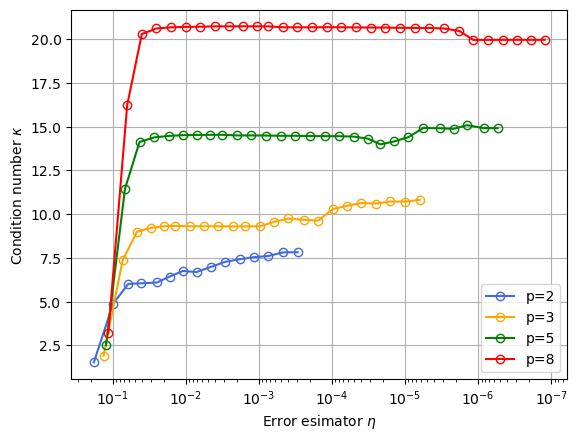

In [16]:
R = np.load("LshapeQ_D_A.npy")
col=('royalblue','orange','green','red')
deg=(2,3,5,8)
for i in range(4):
    data = R[:,i*5+np.array([0,1,2])]
    rows_nonzero = np.any(data != 0, axis=1)

    if np.any(rows_nonzero):
        last = np.flatnonzero(rows_nonzero)[-1]
        data = data[:last + 1]
    else:
        data = data[:0]  # all rows are zero
    eta = data[:,0]
    it = data[:,1]
    kappa = data[:,2]
    #plt.semilogx(eta, it, "o-", color=col[i], markerfacecolor='none')
    plt.semilogx(eta, kappa, "o-", color=col[i], label="p="+str(deg[i]),markerfacecolor='none')
    plt.grid(True)
plt.ylabel("Condition number $\kappa$", size=10)
plt.xlabel("Error esimator $\eta$",size=10)
plt.gca().invert_xaxis()
plt.legend(loc='lower right')
plt.show()

In [90]:
RS = np.load("LshapeQ_S_B.npy")
RD = np.load("LshapeQ_D_B.npy")

In [103]:
R = np.zeros((31,21))
R[:,0]=np.arange(31)
R[:,np.array([1,2,3,6,7,8,11,12,13,16,17,18])]=RS[:,np.array([0,1,2,5,6,7,10,11,12,15,16,17])]
R[:,np.array([4,5,9,10,14,15,19,20])]=RD[:,np.array([1,2,6,7,11,12,16,17])]
np.savetxt('LshapeQ_B', R, fmt=('%d',)+len(degs)*('%1.1e','%d','%1.1f','%d','%1.1f'), delimiter = ' & ', newline='\\\\\n')

In [104]:
R

array([[0.00000e+00, 1.81772e-01, 4.00000e+00, 1.17642e+00, 4.00000e+00, 1.17709e+00, 1.33957e-01, 5.00000e+00, 1.41596e+00, 5.00000e+00, 1.41659e+00, 1.23937e-01, 6.00000e+00, 1.88065e+00, 6.00000e+00, 1.88124e+00, 1.15400e-01, 7.00000e+00, 2.43981e+00, 7.00000e+00, 2.44035e+00],
       [1.00000e+00, 9.89401e-02, 1.10000e+01, 2.45420e+00, 9.00000e+00, 2.17944e+00, 7.31248e-02, 1.30000e+01, 3.00305e+00, 1.20000e+01, 2.65972e+00, 6.81749e-02, 1.50000e+01, 4.11569e+00, 1.40000e+01, 3.59441e+00, 6.35685e-02, 1.70000e+01, 5.43652e+00, 1.70000e+01, 4.94670e+00],
       [2.00000e+00, 6.14843e-02, 1.20000e+01, 2.66855e+00, 1.10000e+01, 2.38613e+00, 4.65738e-02, 1.40000e+01, 3.40559e+00, 1.30000e+01, 2.87906e+00, 4.30382e-02, 1.70000e+01, 4.61345e+00, 1.60000e+01, 3.98488e+00, 4.00520e-02, 2.00000e+01, 6.04331e+00, 1.90000e+01, 5.39312e+00],
       [3.00000e+00, 4.07207e-02, 1.30000e+01, 2.66568e+00, 1.20000e+01, 2.37069e+00, 3.01605e-02, 1.50000e+01, 3.40664e+00, 1.40000e+01, 2.84546e+00, 2.7

In [7]:
degs=(2,3,5,8)

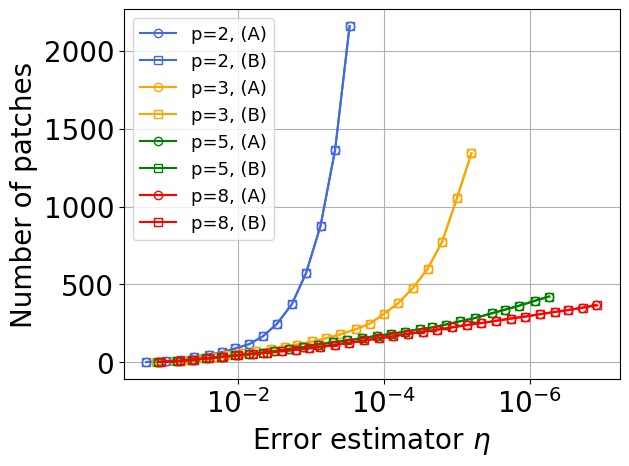

In [25]:
RA = np.load("LshapeQ_S_A.npy")
RB = np.load("LshapeQ_S_B.npy")
col=('royalblue','orange','green','red')
for i in range(4):
    data1 = RA[:,i*5+np.array([0,3,4])]
    data2 = RB[:,i*5+np.array([0,3,4])]
    eta1=data1[:,0]
    eta2=data2[:,0]
    eta1=eta1[eta1!=0]
    eta2=eta2[eta2!=0]
    # Nprim = data[:,1]
    # eta=eta[eta!=0]
    # Nprim = Nprim[Nprim!=0]
    # Nprim=np.r_[0,Nprim]
    Npatches1 = data1[:,2]
    Npatches2 = data2[:,2]
    Npatches1 = Npatches1[Npatches1!=0]
    Npatches2 = Npatches2[Npatches2!=0]
    #plt.semilogx(eta,Nprim,"o-",color=col[i],markerfacecolor='none',label="$N_\pi$: p="+str(degs[i]))
    plt.semilogx(eta1,Npatches1,"o-",color=col[i],markerfacecolor='none',label="p="+str(degs[i])+", (A)")
    plt.semilogx(eta2,Npatches2,"s-",color=col[i],markerfacecolor='none',label="p="+str(degs[i])+", (B)")
plt.gca().invert_xaxis()
plt.legend(loc="upper left",fontsize=13)
plt.grid(True)
plt.tick_params(axis='both', labelsize=20)
plt.xlabel("Error estimator $\eta$", size=20)
plt.ylabel("Number of patches", size=20)
#plt.show()
plt.savefig('LshapeQ_Patches.pdf', bbox_inches='tight')

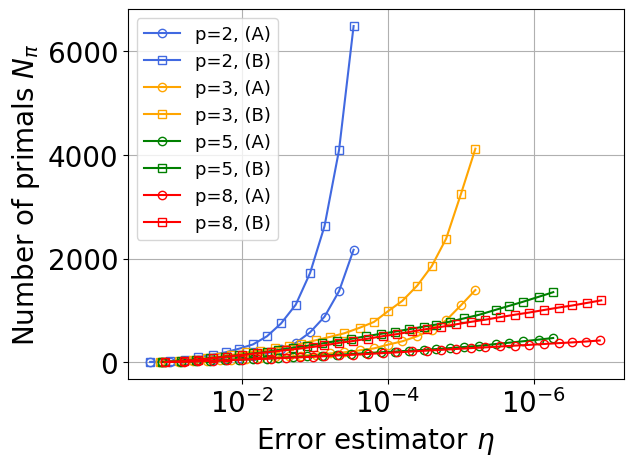

In [26]:
RA = np.load("LshapeQ_S_A.npy")
RB = np.load("LshapeQ_S_B.npy")
col=('royalblue','orange','green','red')
for i in range(4):
    data1 = RA[:,i*5+np.array([0,3,4])]
    data2 = RB[:,i*5+np.array([0,3,4])]
    eta1=data1[:,0]
    eta2=data2[:,0]
    eta1=eta1[eta1!=0]
    eta2=eta2[eta2!=0]
    # Nprim = data[:,1]
    # eta=eta[eta!=0]
    # Nprim = Nprim[Nprim!=0]
    # Nprim=np.r_[0,Nprim]
    Nprim1 = data1[:,1]
    Nprim2 = data2[:,1]
    Nprim1 = Nprim1[Nprim1!=0]
    Nprim2 = Nprim2[Nprim2!=0]
    Nprim1=np.r_[0,Nprim1]
    #plt.semilogx(eta,Nprim,"o-",color=col[i],markerfacecolor='none',label="$N_\pi$: p="+str(degs[i]))
    plt.semilogx(eta1,Nprim1,"o-",color=col[i],markerfacecolor='none',label="p="+str(degs[i])+", (A)")
    plt.semilogx(eta2,Nprim2,"s-",color=col[i],markerfacecolor='none',label="p="+str(degs[i])+", (B)")
plt.gca().invert_xaxis()
plt.legend(loc="upper left",fontsize=13)
plt.grid(True)
plt.tick_params(axis='both', labelsize=20)
plt.xlabel("Error estimator $\eta$", size=20)
plt.ylabel("Number of primals $N_\pi$", size=20)
#plt.show()
plt.savefig('LshapeQ_Primals.pdf', bbox_inches='tight')

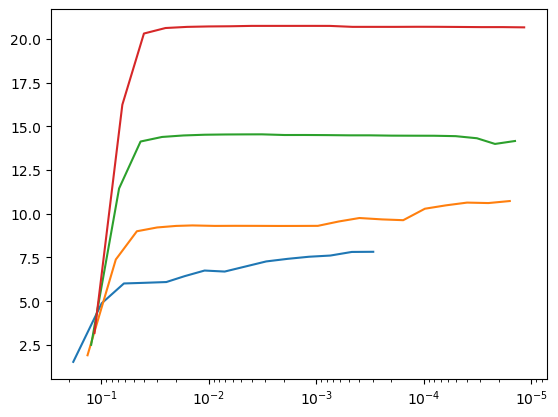

In [42]:
R = np.load("LshapeS_B.npy")
for i in range(4):
    data = R[:,i*5+np.array([0,2])]
    rows_nonzero = np.any(data != 0, axis=1)

    if np.any(rows_nonzero):
        last = np.flatnonzero(rows_nonzero)[-1]
        data = data[:last + 1]
    else:
        data = data[:0]  # all rows are zero
    eta = data[:,0]
    it = data[:,1]
    plt.semilogx(eta,it)
plt.gca().invert_xaxis()
plt.show()

In [33]:
R = np.load("LshapeS_A.npy")

In [37]:
R.shape

(21, 21)

In [36]:
R=np.c_[np.arange(21),R]

In [40]:
np.savetxt('LshapeQ_S_A', R, fmt=('%d',)+len(degs)*('%1.2e','%d','%1.2f','%d','%d'), delimiter = ' & ', newline='\\\\\n')